# Homework 5: Differentiation & Custom DL Framework

## Part 0: Differentiation
Please show the derivation to each answer for each problem. Use LaTeX to write up the answers in the Markdown cells below.

### Exercise 1:
$$ y = x^Tx,  \quad x \in \mathbb{R}^N $$
$$ \frac{\partial y}{\partial x} = ? $$

*Your Answer Here:*
$$y = x^T x = \sum_{i=1}^{N} x_i^2$$
$$\frac{\partial y}{\partial x} = 2x$$

### Exercise 2:
$$ y = tr(AB) \quad A,B \in \mathbb{R}^{N \times N} $$
$$ \frac{\partial}{\partial a_{ij}} y = ? $$
$$ \frac{dy}{dA} = ? $$

*Your Answer Here:*
$$y = tr(AB) = \sum_{i=1}^{N} (AB)_{ii} = \sum_{i=1}^{N} \sum_{k=1}^{N} a_{ik} b_{ki}$$
$$\frac{\partial y}{\partial a_{ij}} = b_{ji}$$ ($a_{ij}$ appears only in the $i=i, k=j$)
$$\frac{\partial}{\partial a_{ij}} y = b_{ji}, \qquad \frac{dy}{dA} = B^T$$



### Exercise 3:
$$ y = x^TAc , \quad A\in \mathbb{R}^{N \times N}, x\in \mathbb{R}^{N}, c\in \mathbb{R}^{N} $$
$$ \frac{dy}{dA} = ? $$

*Your Answer Here:*  
$$y = x^T A c = \sum_{i=1}^{N} \sum_{j=1}^{N} x_i \, a_{ij} \, c_j$$
$$\frac{\partial y}{\partial a_{ij}} = x_i c_j$$
$$\frac{dy}{dA} = x c^T$$


### Exercise 4:
$$ J = || X - AS ||_2^2  , \quad A\in \mathbb{R}^{N \times R} , \quad S\in \mathbb{R}^{R \times M} $$
$$ \frac{dJ}{dS} = ? $$

*Your Answer Here:*
$$E = X - AS$$
$$J = tr(E^T E)$$
$$\frac{dJ}{dS} = \frac{d}{dS} tr\bigl((X-AS)^T(X-AS)\bigr)$$
$$J = tr(X^TX) - tr(X^TAS) - tr(S^TA^TX) + tr(S^TA^TAS)$$
Using the trace derivative identities:
- $\frac{d}{dS} tr(X^T A S) = A^T X$
- $\frac{d}{dS} tr(S^T A^T A S) = 2A^TAS$
$$\frac{dJ}{dS} = -2A^TX + 2A^TAS = -2A^T(X - AS)$$



---
# Part 1: Build Your Own Deep Learning Framework

## Objective
We have seen how to write a Neural Network using raw NumPy (hard) and PyTorch (easy). To truly understand what happens inside `loss.backward()`, you will build a mini-PyTorch from scratch using NumPy. This will be an object-oriented framework.

## Instructions
1. **Do not use PyTorch, TensorFlow, or Autograd.** Use only `numpy`.
2. We provide the base structure (`Module`, `Sequential`).
3. You must implement the `updateOutput` (Forward) and `updateGradInput`/`accGradParameters` (Backward) for:
    * `Linear` (Dense Layer)
    * `ReLU` (Activation)
    * `SoftMax` (Activation)
    * `ClassNLLCriterion` (Loss)
4. Finally, train a model on the MNIST dataset using your framework.

In [1]:
import numpy as np

class Module(object):
    """ Abstract Class for a Neural Network Module. """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        return self.updateOutput(input)

    def backward(self, input, gradOutput):
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput

    def updateOutput(self, input):
        pass

    def updateGradInput(self, input, gradOutput):
        pass

    def accGradParameters(self, input, gradOutput):
        pass

    def zeroGradParameters(self):
        pass

    def getParameters(self):
        return []

    def getGradParameters(self):
        return []

class Sequential(Module):
    """ Container that processes input sequentially through a list of modules. """
    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        self.modules.append(module)

    def updateOutput(self, input):
        self.output = input
        for module in self.modules:
            self.output = module.forward(self.output)
        return self.output

    def backward(self, input, gradOutput):
        # 1. Get the inputs for each layer.
        inputs = [input]
        for i in range(len(self.modules) - 1):
            inputs.append(self.modules[i].output)

        # 2. Iterate backwards
        self.gradInput = gradOutput
        for i in range(len(self.modules) - 1, -1, -1):
            self.gradInput = self.modules[i].backward(inputs[i], self.gradInput)

        return self.gradInput

    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getParameters(self):
        return [x.getParameters() for x in self.modules]

    def getGradParameters(self):
        return [x.getGradParameters() for x in self.modules]

### Task 1: Linear Layer
Implement the fully connected layer.
* **Forward Formula:** $Y = X W^T + b$
* **Gradient Hints:**
    * `gradInput` ($dX$): $gradOutput \cdot W$
    * `gradW` ($dW$): $gradOutput^T \cdot X$
    * `gradb` ($db$): sum of $gradOutput$ over the batch dimension.

In [2]:
class Linear(Module):
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()
        # Xavier Initialization
        stdv = 1. / np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        self.output = np.dot(input, self.W.T) + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.dot(gradOutput, self.W)
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW = np.dot(gradOutput.T, input)
        self.gradb = np.sum(gradOutput, axis=0)
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

### Task 2: Activation Functions
Implement ReLU and SoftMax.
**SoftMax Hint:** Subtract the max value from the input before exponentiating to avoid numerical overflow.
$$\text{SoftMax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum e^{x_j - \max(x)}}$$

In [3]:
class ReLU(Module):
    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * (input > 0)
        return self.gradInput

class SoftMax(Module):
    def updateOutput(self, input):
        shifted_input = input - np.max(input, axis=1, keepdims=True)
        exp_input = np.exp(shifted_input)
        self.output = exp_input / np.sum(exp_input, axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # NOTE: Softmax gradient is mathematically complex.
        # When paired with CrossEntropyLoss, the math simplifies to (predictions - targets).
        # For this homework, you can return a placeholder or implement the true Jacobian if you want a challenge!
        adjustment = self.output * gradOutput
        sum_adjustment = np.sum(adjustment, axis=1, keepdims=True)
        self.gradInput = self.output * (gradOutput - sum_adjustment)
        return self.gradInput

### Task 3: Criterion (Loss Function)
Implement the Negative Log Likelihood (Cross Entropy) for multiclass classification.

In [4]:
class ClassNLLCriterion(object):
    def updateOutput(self, input, target):
        # input: probability distribution (output of SoftMax)
        # target: one-hot encoded targets

        # Trick to avoid numerical errors (log(0))
        eps = 1e-15
        input_clamp = np.clip(input, eps, 1 - eps)
        log_probs = np.log(input_clamp)
        ce_matrix = target * log_probs
        self.output = -np.mean(np.sum(ce_matrix, axis=1))
        return self.output

    def updateGradInput(self, input, target):
        # The gradient of Cross Entropy + SoftMax simplifies beautifully to: (prediction - target) / batch_size
        self.gradInput = (input - target) / input.shape[0]
        return self.gradInput


### Task 4: Putting it all together (MNIST)
1. Load MNIST data (`sklearn.datasets.load_digits`).
2. Preprocess: Flatten images, normalize to [0,1], One-hot encode targets.
3. Build a `Sequential` model: Linear -> ReLU -> Linear -> SoftMax.
4. Write a training loop using SGD.
5. Plot the loss.

Epoch 1/50, Loss: 2.3103
Epoch 2/50, Loss: 2.2679
Epoch 3/50, Loss: 2.2240
Epoch 4/50, Loss: 2.1764
Epoch 5/50, Loss: 2.1222
Epoch 6/50, Loss: 2.0606
Epoch 7/50, Loss: 1.9864
Epoch 8/50, Loss: 1.9012
Epoch 9/50, Loss: 1.7976
Epoch 10/50, Loss: 1.6773
Epoch 11/50, Loss: 1.5487
Epoch 12/50, Loss: 1.4086
Epoch 13/50, Loss: 1.2717
Epoch 14/50, Loss: 1.1370
Epoch 15/50, Loss: 1.0223
Epoch 16/50, Loss: 0.9150
Epoch 17/50, Loss: 0.8186
Epoch 18/50, Loss: 0.7319
Epoch 19/50, Loss: 0.6610
Epoch 20/50, Loss: 0.6037
Epoch 21/50, Loss: 0.5539
Epoch 22/50, Loss: 0.5114
Epoch 23/50, Loss: 0.4762
Epoch 24/50, Loss: 0.4459
Epoch 25/50, Loss: 0.4191
Epoch 26/50, Loss: 0.3968
Epoch 27/50, Loss: 0.3754
Epoch 28/50, Loss: 0.3568
Epoch 29/50, Loss: 0.3417
Epoch 30/50, Loss: 0.3282
Epoch 31/50, Loss: 0.3144
Epoch 32/50, Loss: 0.3034
Epoch 33/50, Loss: 0.2924
Epoch 34/50, Loss: 0.2827
Epoch 35/50, Loss: 0.2739
Epoch 36/50, Loss: 0.2657
Epoch 37/50, Loss: 0.2597
Epoch 38/50, Loss: 0.2522
Epoch 39/50, Loss: 0.

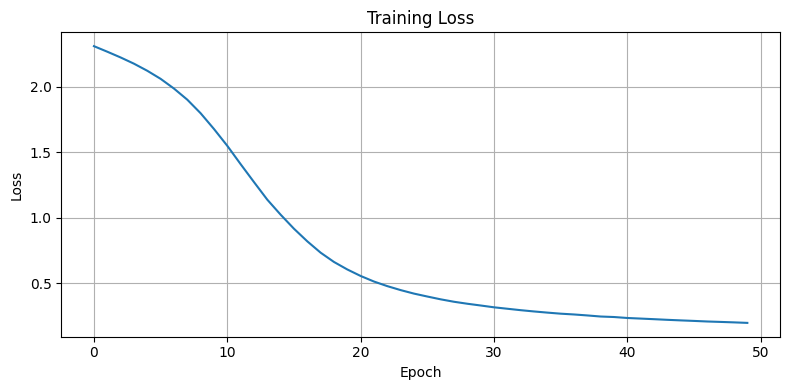

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 1. Load Data
digits = load_digits()
X = digits.images
y = digits.target

# 2. Preprocessing
X = X.reshape(X.shape[0], -1)
X = X / 16.0

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# FIX: split y_encoded (one-hot) alongside X and y_int,
# so batch targets are always (batch, 10) arrays, not integer labels.
X_train, X_test, y_train_enc, y_test_enc, y_train_int, y_test_int = train_test_split(
    X, y_encoded, y, test_size=0.2, random_state=42
)

# 3. Model Definition
net = Sequential()
net.add(Linear(X_train.shape[1], 128))
net.add(ReLU())
net.add(Linear(128, 10))
net.add(SoftMax())

criterion = ClassNLLCriterion()

# 4. Training Loop
epochs = 50
batch_size = 32
learning_rate = 0.1
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    # shuffled data each epoch for better SGD convergence
    idx = np.random.permutation(X_train.shape[0])
    X_train_shuf = X_train[idx]
    y_train_shuf = y_train_enc[idx]

    for i in range(0, X_train.shape[0], batch_size):
        batch_X = X_train_shuf[i:i+batch_size]
        batch_y = y_train_shuf[i:i+batch_size]

        net.zeroGradParameters()

        # Forward Pass
        output = net.forward(batch_X)
        loss = criterion.updateOutput(output, batch_y)

        # Backward Pass
        grad = criterion.updateGradInput(output, batch_y)
        net.backward(batch_X, grad)

        # Update Parameters (SGD)
        for layer in net.modules:
            for param, grad_p in zip(layer.getParameters(), layer.getGradParameters()):
                param -= learning_rate * grad_p

        epoch_loss += loss

    num_batches = X_train.shape[0] / batch_size
    losses.append(epoch_loss / num_batches)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss / num_batches:.4f}")


# 5. Plot the loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()
